- To-Do:
  - [ ] adicionar Ruler


In [4]:
# %pip install pip
%pip install -q matplotlib==3.10.8

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict
from collections import Counter

- Qualidade dos signos:
  - Cardinal (Início/ação): Áries, Câncer, Libra, Capricórnio
  - Fixo (Sustentação/estabilidade): Touro, Leão, Escorpião, Aquário
  - Mutável (Adaptação/finalização): Gêmeos, Virgem, Sagitário, Peixes
- Elementos dos signos:
  - Fogo: Áries, Leão, Sagitário
  - Terra: Touro, Virgem, Capricórnio
  - Ar: Gêmeos, Libra, Aquário
  - Água: Câncer, Escorpião, Peixes
- Polaridade: (Masculinos = Ímpares, Terra e água; Femininos = Pares; Fogo e ar)
  - Masculinos (yang, ativo ou extrovertido, diurno ou positivo): Áries, Gêmeos, Leão, Libra, Sagitário, Aquário
  - Femininos (yin, passivo ou introvertido, noturno ou negativo): Touro, Câncer, Virgem, Escorpião, Capricórnio, Peixes


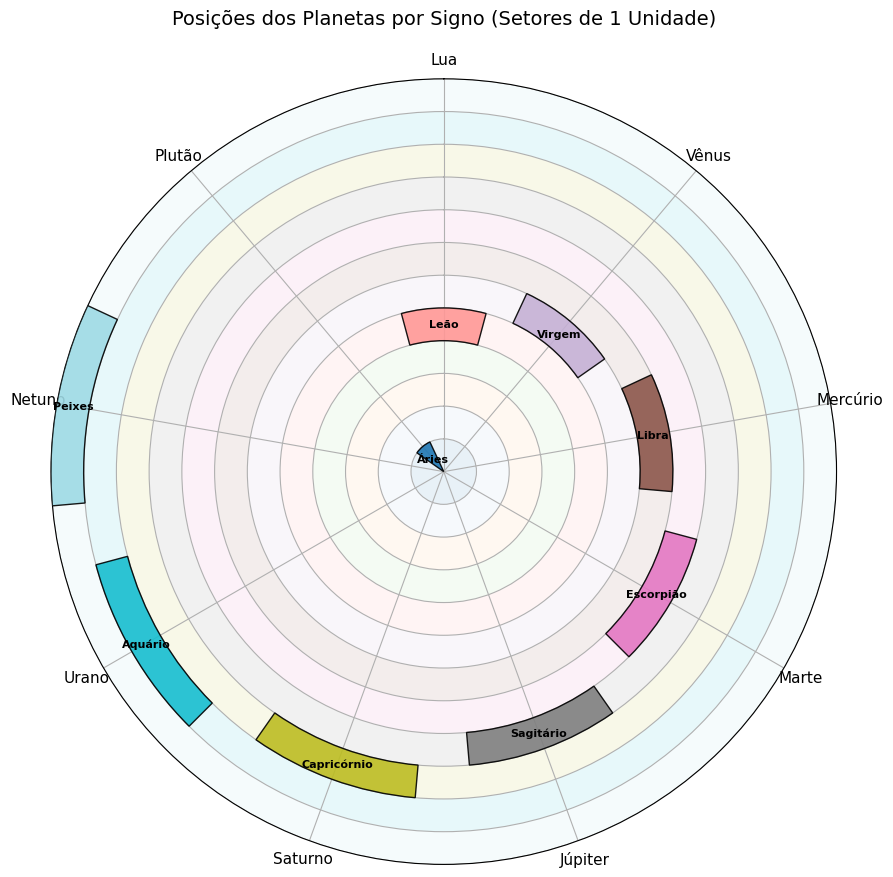

In [ ]:
''' Este código plota um gráfico de radar para as posições dos planetas por signo, usando a biblioteca Matplotlib. '''


PLANETS = [
    {'name': 'Mercúrio', 'symbol': '☿', 'element': 'Ar',
        'quality': 'Cardinal', 'polarity': 'Masculino'},
    {'name': 'Vênus', 'symbol': '♀', 'element': 'Terra',
        'quality': 'Fixo', 'polarity': 'Feminino'},
    {'name': 'Terra', 'symbol': '⊕', 'element': 'Terra',
        'quality': 'Fixo', 'polarity': 'Feminino'},
    {'name': 'Marte', 'symbol': '♂', 'element': 'Fogo',
        'quality': 'Mutável', 'polarity': 'Masculino'},
    {'name': 'Júpiter', 'symbol': '♃', 'element': 'Ar',
        'quality': 'Cardinal', 'polarity': 'Masculino'},
    {'name': 'Saturno', 'symbol': '♄', 'element': 'Terra',
        'quality': 'Fixo', 'polarity': 'Feminino'},
    {'name': 'Urano', 'symbol': '♅', 'element': 'Fogo',
        'quality': 'Mutável', 'polarity': 'Masculino'},
    {'name': 'Netuno', 'symbol': '♆', 'element': 'Ar',
        'quality': 'Cardinal', 'polarity': 'Masculino'},
    {'name': 'Plutão', 'symbol': '♇', 'element': 'Terra',
        'quality': 'Fixo', 'polarity': 'Feminino'},
    {'name': 'Lua', 'symbol': '☽', 'element': 'Fogo',
        'quality': 'Mutável', 'polarity': 'Feminino'},
    {'name': 'Sol', 'symbol': '☉', 'element': 'Ar',
        'quality': 'Cardinal', 'polarity': 'Masculino'},
]

SIGNS = [
    {
        'name': 'Áries',
        'Abreviation': 'Ari',
        'Number': 0, 'Degree': 0, 'Symbol': '♈︎',
        'Emoji': '♈',
        'Translation': 'Carneiro',
        'Element': 'Fogo',
        'Quality': 'Cardinal',
        'Polarity': 'Masculino',
        'Ruler': 'Marte', 'Detriment': ['Vênus', 'Eris'],
        'Exaltation': 'Sol',
        'Fall': 'Saturno',
        'House': 1,
        'Oposed': 'Libra'},
    {
        'name': 'Touro',
        'Abreviation': 'Tau',
        'Number': 1,
        'Degree': 30,
        'Symbol': '♉︎',
        'Emoji': '♉',
        'Translation': 'Touro',
        'Element': 'Terra',
        'Quality': 'Fixo',
        'Polarity': 'Feminino',
        'Ruler': 'Vênus',
        'Detriment': ['Marte', 'Plutão'],
        'Exaltation': 'Lua',
        'Fall': 'Urano',
        'House': 2,
        'Oposed': 'Escorpião'},
    {
        'name': 'Gêmeos',
        'Abreviation': 'Gem',
        'Number': 2,
        'Degree': 60,
        'Symbol': '♊︎',
        'Emoji': '♊',
        'Translation': 'Geminado',
        'Element': 'Ar',
        'Quality': 'Mutável',
        'Polarity': 'Masculino',
        'Ruler': 'Mercúrio',
        'Detriment': 'Júpiter',
        'Exaltation': ['North Node', 'Ceres'],
        'Fall': ['South Node', 'Eris'],  'House': 3,
        'Oposed': 'Sagitário'},
    {
        'name': 'Câncer',
        'Abreviation': 'Can',
        'Number': 3,
        'Degree': 90,
        'Symbol': '♋︎',
        'Emoji': '♋',
        'Translation': 'Caranguejo',
        'Element': 'Água',
        'Quality': 'Cardinal',
        'Polarity': 'Feminino',
        'Ruler': 'Lua',
        'Detriment': 'Saturno',
        'Exaltation': {'en': 'Júpiter', 'pt': ['Júpiter', 'Netuno']},
        'Fall': 'Marte',
        'House': 4,
        'Oposed': 'Capricórnio'},
    {
        'name': 'Leão',
        'Abreviation': 'Leo',
        'Number': 4,
        'Degree': 120,
        'Symbol': '♌︎',
        'Emoji': '♌',
        'Translation': 'Leão',
        'Element': 'Fogo',
        'Quality': 'Fixo',
        'Polarity': 'Masculino',
        'Ruler': 'Sol',
        'Detriment': {'en': ['Urano', 'Netuno'], 'pt': 'Urano'},
        'Exaltation': {'Modern': 'Netuno', 'pt': 'Plutão'},
        'Fall': {'Traditional': None, 'Modern': 'Plutão', 'pt': 'Mercúrio'},
        'House': 5,
        'Oposed': 'Aquário'},
    {
        'name': 'Virgem',
        'Abreviation': 'Vir',
        'Number': 5,
        'Degree': 150,
        'Symbol': '♍︎',
        'Emoji': '♍',
        'Translation': 'Donzela',
        'Element': 'Terra',
        'Quality': 'Mutável',
        'Polarity': 'Feminino',
        'Ruler': {'Traditional': 'Mercúrio', 'Modern': 'Ceres'},
        'Detriment': ['Júpiter', 'Netuno'],
        'Exaltation': {'en': 'Vênus', 'pt': None},
        'Fall': 'Vênus',
        'House': 6,
        'Oposed': 'Peixes'},
    {
        'name': 'Libra',
        'Abreviation': 'Lib',
        'Number': 6,
        'Degree': 180,
        'Symbol': '♎︎',
        'Emoji': '♎',
        'Translation': 'Escalas',
        'Element': 'Ar',
        'Quality': 'Cardinal',
        'Polarity': 'Masculino',
        'Ruler': ['Vênus', 'Eris'],
        'Detriment': 'Marte',
        'Exaltation': 'Saturno',
        'Fall': 'Sol',
        'House': 7,
        'Oposed': 'Áries'},
    {
        'name': 'Escorpião',
        'Abreviation': 'Sco',
        'Number': 7,
        'Degree': 210,
        'Symbol': '♏︎',
        'Emoji': '♏',
        'Translation': 'Escorpião',
        'Element': 'Água',
        'Quality': 'Fixo',
        'Polarity': 'Feminino',
        'Ruler': {'Traditional': 'Marte', 'Modern': 'Plutão', 'Descending Lunar Node; Vedic Astrology': 'Ketu'},
        'Detriment': 'Vênus',
        'Exaltation': 'Urano',
        'Fall': 'Lua',
        'House': 8,
        'Oposed': 'Touro'},
    {
        'name': 'Sagitário',
        'Abreviation': 'Sgr',
        'Number': 8,
        'Degree': 240,
        'Symbol': '♐︎',
        'Emoji': '♐',
        'Translation': 'Arqueiro',
        'Element': 'Fogo',
        'Quality': 'Mutável',
        'Polarity': 'Masculino',
        'Ruler': 'Júpiter',
        'Detriment': 'Mercúrio',
        'Exaltation': ['South Node', 'Eris'],
        'Fall': ['Ceres', 'North Node'],
        'House': 9,
        'Oposed': 'Gêmeos'},
    {
        'name': 'Capricórnio',
        'Abreviation': 'Cap',
        'Number': 9,
        'Degree': 270,
        'Symbol': '♑︎',
        'Emoji': '♑',
        'Translation': 'Tendo chifres de cabra',
        'Element': 'Terra',
        'Quality': 'Cardinal',
        'Polarity': 'Feminino',
        'Ruler': 'Saturno',
        'Detriment': 'Lua',
        'Exaltation': 'Marte',
        'Fall': {'en': 'Júpiter', 'pt': ['Júpiter', 'Netuno']},
        'House': 10,
        'Oposed': 'Câncer'},
    {
        'name': 'Aquário',
        'Abreviation': 'Aqr',
        'Number': 10,
        'Degree': 300,
        'Symbol': '♒︎',
        'Emoji': '♒',
        'Translation': 'Carregador de água',
        'Element': 'Ar',
        'Quality': 'Fixo',
        'Polarity': 'Masculino',
        'Ruler': {'Traditional': 'Saturno', 'Modern': 'Urano', 'Ascending Lunar Node, Vedic Astrology': 'Rahu'},
        'Detriment': 'Sol',
        'Exaltation': {'Traditional': None, 'Modern': 'Pluto', 'pt': 'Mercúrio'},
        'Fall': {'en': 'Netuno', 'pt': 'Plutão'},
        'House': 11,
        'Oposed': 'Leão'},
    {
        'name': 'Peixes',
        'Abreviation': 'Psc',
        'Number': 11,
        'Degree': 330,
        'Symbol': '♓︎',
        'Emoji': '♓',
        'Translation': 'Peixes',
        'Element': 'Água',
        'Quality': 'Mutável',
        'Polarity': 'Feminino',
        'Ruler': {'Traditional': 'Júpiter', 'Modern': 'Netuno'},
        'Detriment': 'Mercúrio',
        'Exaltation': 'Vênus',
        'Fall': None,
        'House': 12,
        'Oposed': 'Virgem'},
]


def plot_map(posicoes_planetas: Dict[str, str]):
    """Plota blocos polares: cada planeta ocupa apenas 1 unidade do signo correspondente."""
    signos = [
        "Áries", "Touro", "Gêmeos", "Câncer", "Leão", "Virgem",
        "Libra", "Escorpião", "Sagitário", "Capricórnio", "Aquário", "Peixes"
    ]
    valor_signo = {s: i + 1 for i, s in enumerate(signos)}

    planetas = list(posicoes_planetas.keys())
    valores = np.array([valor_signo[posicoes_planetas[p]] for p in planetas])

    N = len(planetas)
    angulos = np.linspace(0, 2 * np.pi, N, endpoint=False)
    # largura de cada setor no eixo do planeta
    largura = (2 * np.pi / N) * 0.75

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Eixo angular = planetas
    ax.set_xticks(angulos)
    ax.set_xticklabels(planetas, fontsize=11)

    # Eixo radial = signos (1..12)
    ax.set_yticks(range(1, 13))
    # ax.set_yticklabels(signos, fontsize=9)
    ax.set_yticklabels([])  # Esconde os rótulos numéricos dos signos
    ax.set_ylim(0, 12)

    # Paleta por signo (12 cores)
    cores_signos = plt.cm.tab20(np.linspace(0, 1, 12))

    # Fundo: um anel colorido para cada signo (faixas 0-1, 1-2, ..., 11-12)
    for i in range(12):
        ax.bar(
            0,                    # começa em theta=0
            1,                    # altura da faixa
            width=2 * np.pi,      # círculo completo
            bottom=i,             # faixa radial i -> i+1
            align="edge",
            color=cores_signos[i],
            edgecolor="none",
            alpha=0.10,           # transparência do fundo
            zorder=0
        )
    # Cada planeta vira um único bloco de altura 1 no "anel" do signo
    bars = ax.bar(
        angulos,
        np.ones(N),
        width=largura,
        bottom=valores - 1,
        align="center",
        edgecolor="black",
        linewidth=1.0,
        zorder=3
    )

    # Label do signo dentro da seção de cada planeta
    for i, bar in enumerate(bars):
        signo_atual = posicoes_planetas[planetas[i]]

        # Centro angular da barra
        theta = bar.get_x() + bar.get_width() / 2

        # Centro radial da faixa do signo (altura 1)
        r = bar.get_y() + bar.get_height() / 2

        ax.text(
            theta,
            r,
            signo_atual,
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color="black",
            zorder=4
        )
    # Cor do bloco conforme o signo daquele planeta
    for i, bar in enumerate(bars):
        idx_signo = int(valores[i] - 1)  # 0..11
        bar.set_facecolor(cores_signos[idx_signo])
        bar.set_alpha(0.9)

    ax.set_title(
        "Posições dos Planetas por Signo (Setores de 1 Unidade)", pad=20, fontsize=14)
    plt.tight_layout()
    plt.show()


MY_MAP = {  # Posições dos planetas por signo (edite conforme seu mapa)
    "Lua": "Leão",
    "Vênus": "Virgem",
    "Mercúrio": "Libra",
    "Marte": "Escorpião",
    "Júpiter": "Sagitário",
    "Saturno": "Capricórnio",
    "Urano": "Aquário",
    "Netuno": "Peixes",
    "Plutão": "Áries"
}

plot_map(MY_MAP)